**Домашнее задание по теме "Обучение с подкреплением"**

Польский Андрей.

Вариант Light.

# Импорт библиотек

In [1]:
pip install tensorflow==1.15

     |████████████████████████████████| 412.3MB 38kB/s 
     |████████████████████████████████| 3.8MB 40.5MB/s 
     |████████████████████████████████| 51kB 9.6MB/s 
     |████████████████████████████████| 512kB 49.7MB/s 
  Created wheel for gast: filename=gast-0.2.2-cp36-none-any.whl size=7540 sha256=4c51a69d56cdb54c57782123e633259adaeffeb316f7918d9a17849256ad20c9
  Stored in directory: /root/.cache/pip/wheels/5c/2e/7e/a1d4d4fcebe6c381f378ce7743a3ced3699feb89bcfbdadadd
Successfully built gast
ERROR: tensorflow-probability 0.12.1 has requirement gast>=0.3.2, but you'll have gast 0.2.2 which is incompatible.
  Found existing installation: tensorboard 2.4.1
    Uninstalling tensorboard-2.4.1:
      Successfully uninstalled tensorboard-2.4.1
  Found existing installation: gast 0.3.3
    Uninstalling gast-0.3.3:
      Successfully uninstalled gast-0.3.3
  Found existing installation: tensorflow-estimator 2.4.0
    Uninstalling tensorflow-estimator-2.4.0:
      Successfully uninstalled tens

In [2]:
pip install keras==2.3

     |████████████████████████████████| 378kB 15.2MB/s 
  Found existing installation: Keras 2.4.3
    Uninstalling Keras-2.4.3:
      Successfully uninstalled Keras-2.4.3


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import gym # загружаем тренажер Gym из платформы OpenAi, представляющей среду для работы над обучением с подкреплением
import numpy as np
import keras # импортируем нейросетевую библиотеку
from keras.models import Model, load_model #загружаем абстрактный класс модели и метод загрузки предобученной модели
from keras.layers import Dense, Flatten, Input, Lambda, Conv2D, MaxPooling2D, Reshape, Multiply
from keras.optimizers import RMSprop, Adam
import time
import matplotlib.pyplot as plt

%matplotlib inline

Using TensorFlow backend.


# Взгляд на игру

In [5]:
env = gym.make('Pong-v0') # создаем среду игры в Понг средствами OpenAi Gym
observation = env.reset() # задаем начальное состояние среды, которое наблюдает агент
observation.shape # взглянем на форму состояния среды
# и увидим, что это изображение размером 210х160 с тремя RGB каналами

(210, 160, 3)

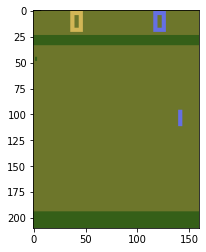

In [6]:
plt.imshow(observation)
plt.show()

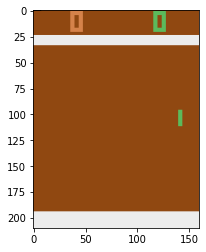

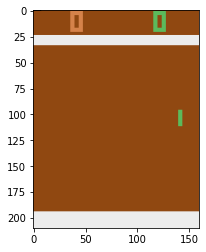

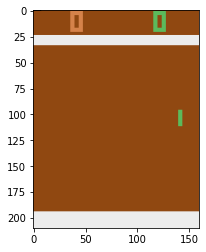

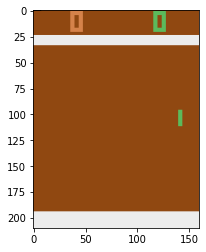

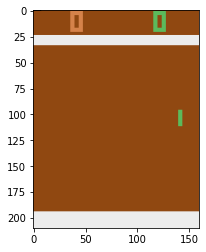

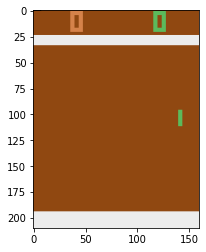

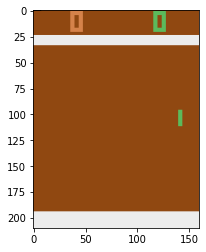

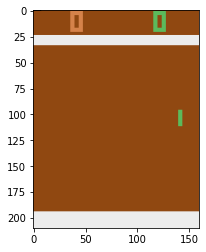

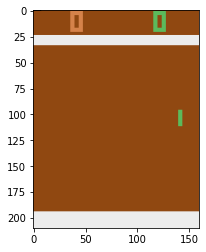

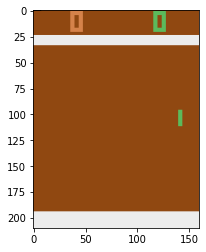

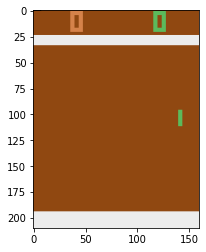

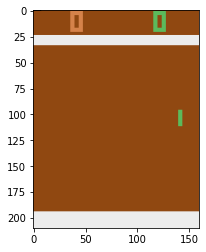

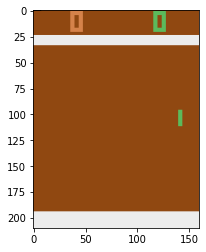

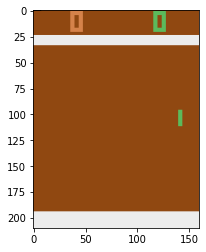

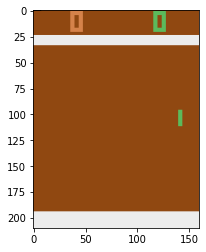

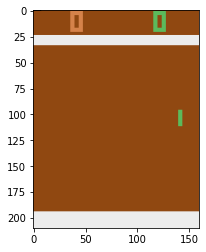

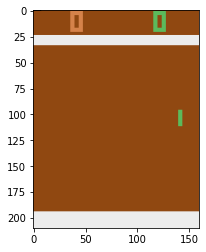

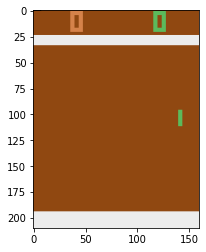

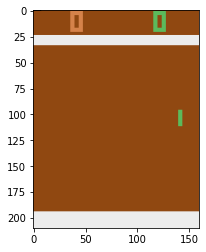

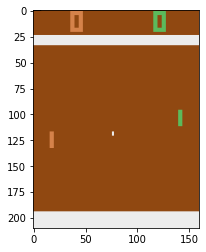

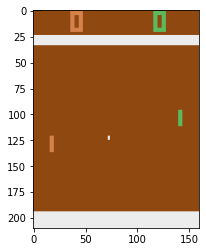

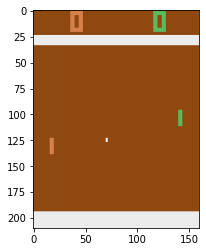

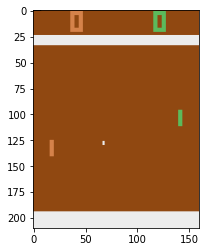

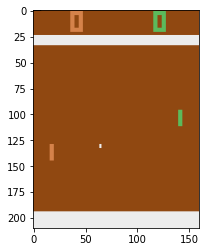

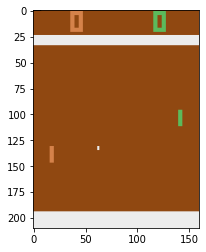

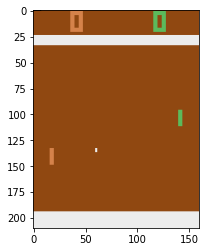

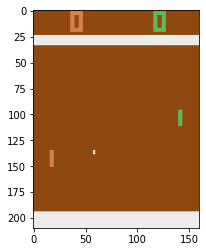

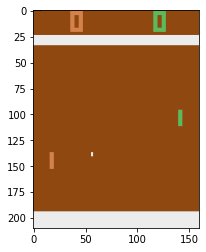

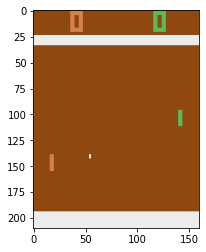

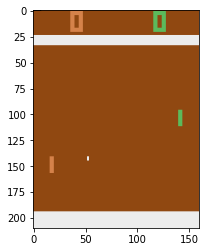

In [7]:
# В понге:
# 0 цифровое обозначение если ракетка 'остаётся на месте'
# 2 цифровое обозначение для действия ракеткой 'сдвинуться вверх'
# 3 цифровое обозначение для действия ракеткой 'сдвинуться вниз'
 
 # Прогиграем игру вперед на 30 кадров, чтобы увидеть полную сцену игры
for i in range(30):
  observation, reward, done, info = env.step(0) # 0 обозначает, что мы ничего не делаем
  plt.imshow(observation) # Взглянем на текущее состояние среды: наш агент владеет зеленой ракеткой, появился соперник и мяч
  plt.show()

# step - такт, шаг в игре: принимает (action, действие агента), возвращает кортеж (observation, reward, done, info)
# observation (object) - текущее состояние среды, которое наблюдает агент(пиксели)
# reward (float) - награда за совершённое действие
# done (True or False) - обозначает завершился ли игровой эпизод (в понге до победы 21 очко)
# info (dict) - вспомогательная диагностическая информация, типа кол-во оставшихся жизней(неактуально для понга)

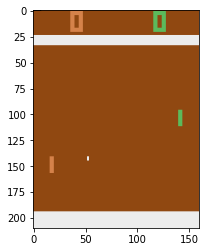

In [8]:
# Policy (политику, стратегию) агента будет позже задавать нейросеть
# мы подадим ей разницу между новым и предыдущим кадром, чтобы отслеживалось смещенеи мяча/ракеток и данные были понятными
newObservation, reward, done, info = env.step(2) # задаем очередным шагом следующий кадр, причем смещая ракетку наверх
plt.imshow(observation)
plt.show()


# Предобработка данных

In [9]:
# Объявим функцию предобработки данных для подачи в нейросеть
# Избавимся от всего лишнего (фон, размер и.т.п.), оставив лишь мяч и ракетки

def preprocessFrames(newFrame, lastFrame): # подаем на вход новый и предыдущий кадр
  nFrame = newFrame.astype(np.int32) # переводим в целочисленный тип новый кадр
  nFrame[nFrame==144] = 0 # удаляем цвета фона в новом кадре (144 и 72 - значения каналов, дающих оранжевый цвет, зануляем)
  nFrame[nFrame==72] = 0
  lFrame = lastFrame.astype(np.int32)
  lFrame[lFrame==144] = 0
  lFrame[lFrame==72] = 0
  deltaFrame = nFrame - lFrame
  #отрезаем верхнюю и нижнюю (неиформативныю) части экрана, по 35 сверху и снизу
  deltaFrame = deltaFrame[35:195] # осталась картинка 160:160
  # делаем сжатие кадра в два раза по обеим сторонам и осатвляем монотонный канал
  deltaFrame = deltaFrame[::2,::2, 0]
  # масштабирование чисел от 0 до 1
  maxValue = deltaFrame.max() if deltaFrame.max()>abs(deltaFrame.min()) else abs(deltaFrame.min())
  if maxValue != 0: 
    deltaFrame=deltaFrame/maxValue

  return deltaFrame # функция вернет разницу между кадрами в оптимальном виде

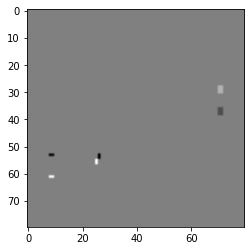

In [10]:
plt.imshow(preprocessFrames(newObservation, observation), plt.cm.gray) # выведем результат обработки наших кадров
# смещение здесь - это шаг от черного пиксея к светлому

In [11]:
preprocessFrames(newObservation, observation) # выведем массив для этого состояния среды (кадра)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [12]:
preprocessFrames(newObservation, observation).shape # Выведем форму массива

(80, 80)

In [ ]:
# Состоянием среды будет картинка 80х80, полученная вычитанием двух последовательных кадров, где по итогу все будет 
# заполнено нулями, а в местах смещения мяча или ракетки будут не нулевые значения.
# далее keras'oм создадим policy, которая на основании состояния картики выбирает действия.
# Output сети - вероятность того, что нужно двигаться вверх.

# Моделируем сеть

In [13]:
# Простая сеть с двумя слоями из 200 нейронов в скрытом слое и сигмоидой на выходе

inputs = Input(shape=(80, 80)) # на входном слое сетки изображение 80х80
flattenedLayer = Flatten()(inputs) # переводим в вектор
fullConnected = Dense(units=200, activation='relu', use_bias=False)(flattenedLayer) # Задали 200 нейронов и активацию relu
sigmoidOutput = Dense(1, activation='sigmoid', use_bias=False)(fullConnected)
policyNetworkModel = Model(inputs=inputs, outputs=sigmoidOutput)
policyNetworkModel.summary()


Instructions for updating:
If using Keras pass *_constraint arguments to layers.
Model: "model_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         (None, 80, 80)            0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 6400)              0         
_________________________________________________________________
dense_1 (Dense)              (None, 200)               1280000   
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 200       
Total params: 1,280,200
Trainable params: 1,280,200
Non-trainable params: 0
_________________________________________________________________


# Задаем функцию потерь в соответствии с вознаграждением

In [14]:
# episode - одна тренировочная игра от анчала партии до перезагрузки (розыгрыш эпизода до 21 очка, после победы или поражения вызываем reset)
episodeReward = Input(shape=(1,), name='episodeReward') # задаем награду за эпизод


In [15]:
###############################
# Функция потерь в керасе имеет вид def loss(yTrue, yPred): ... А так как нам надо в нее включить reward  в loss,
# создаем функцию rewardedLoss вокруг нее, чтобы на входе добавить episodeReward
###############################

def rewardedLoss(episodeReward): # задаем новую функцию потерь, принимающую episodeReward
  def loss(yTrue, yPred):
    # подаем в качестве yTrue фактически сделанное действие 
    # если фактическое сделанное действие было движением вверх - подаем 1 на yTrue, если нет, то подаем 0.
    # yPred - выход сетки (вероятность выбора движения вверх)
    # мы не подаем yPred  в нейронку, его вычисляет керас

    # сначала log(0) и log(1) не определены - загоняем yPred между значениями
    tmpPred = Lambda(lambda x: keras.backend.clip(x,0.05,0.95))(yPred)
    # вычисляем логарифм вероятности. yPred - вероятность выбора движения вверх.
    # yTrue = 1, когда фактически выбрано движение вверх, 0 - когда вниз
    # формула похожа на кросс-энтропиюв керасе, но здесь мы ее прописываем вручную, чтобы умнодить на значение награды
    tmpLoss = Lambda(lambda x: -yTrue*keras.backend.log(x)-(1-yTrue)*(keras.backend.log(1-x)))(tmpPred)
    # обновленная функция потерь - "функция политики"
    policyLoss = Multiply()([tmpLoss, episodeReward]) # добавляем в loss умножение на награду за эпизод
    return policyLoss # ввели обновленную функцию политики
  return loss # возвращаем обновленную функцию политики

In [ ]:
####################
# создаем керас-оптимизатор и нейронку для обучения
####################
episodeReward = Input(shape=(1,), name='episodeReward')  # задаем награду за эпизод
policyNetworkTrain = Model(inputs=[inputs, episodeReward], outputs=sigmoidOutput) # создаем сеть с добавлением на вход награды

myOptimizer = RMSprop(lr=0.0001)
policyNetworkTrain.compile(optimizer=myOptimizer, loss=rewardedLoss(episodeReward)) # компилируем сеть с новой функцией потерь policy

# Генерация игрового эпизода с участием нейросети

In [16]:
##############################
# Создадим функцию, которая будет генерировать игровой эпизод с участием нейросети
##############################
# игра начнется с того, что в новом эпизоде наш агент сделает движение (actualAction) вверх с вероятностью (upProbability),
# которую предсказала наша сетка policyNetWork, принявшая на вход состояние среды reshapedInput с подбитой под сеть формой
# reshapeInput же получили из состояния processedNetworkInput, которое представляет собой разницу между новым и пр5дыдущим кадром
# полученными функцией preprocessFrames.

def generateEpisode(policyNetwork): # подаем на вхорд функции модель нейросети
  statesList = [] # список состояний в течение эпизода, размер (х, 80, 80)
  upDownActionList = [] # список движений в течение эпизода (вверх - 1, вниз - 0)
  rewardsList = [] #список наград за каждое действие
  networkOutputList = [] # на выходе нейросети вероятность того, нужно идти вверх. Собраем список вероятностей на каждом шаге
  env = gym.make("Pong-v0") # создаем среду
  observation = env.reset() # перезагружаем состояние среды
  newObservation = observation # получаем новое сосотояние, которое наблюдает агент
  done = False # игровой эпизод активен (не завершен)

  while done == False: #пока игровой эпизоде не завершен
    # на вход сети будет подаваться очередное состояние, разница между кадрами
    processedNetworkInput = np.expand_dims(preprocessFrames(newFrame=newObservation, lastFrame=observation), axis=2)
    statesList.append(processedNetworkInput) #добавядем в список состояний
    reshapedInput = np.expand_dims(processedNetworkInput, axis=0) # размер х - (80, 80, 1) делаем размерность (х, (1, 80, 80, 1))

    upProbability = policyNetwork.predict(reshapedInput, batch_size=1)[0][0] # задаем вероятность шага наверх
    networkOutputList.append(upProbability) # добавляем в список вероятностей идити вверх нп каждом шаге
    actualAction = np.random.choice(a=[2, 3], size=1, p=[upProbability, 1-upProbability])
    # сделаем фактический шаг либо вверх (2) с вероятностью upProbability или вниз(3) с обратной вероятностью

    if actualAction == 2: # пошли вверх
      upDownActionList.append(1) # добавляем 1 в список движений в течение  эпизода
    else: # если не пошли вверх
      upDownActionList.append(0) # добавляем 0
    
    observation = newObservation # текущий newObservation записываем как старый перед тем, как сделать новый шаг
    newObservation, reward, done, info = env.step(actualAction) # сделали новый шаг, получили состояние и награду

    rewardsList.append(reward) # добавли текущую награду в список
    
    if done:  # если игровой эпизод закончен
      break

  env.close() # закрываем текущую среду
  return statesList, upDownActionList, rewardsList, networkOutputList
  # функция возвращает список состояний в течение эпизода, список движений в течение эпизода, список наград за каждое действие
  # и список вероятностей того, что нужно идти вверх

In [ ]:
#############################
# Сгенерируем эпизод игры с необученной сетью
#############################
statesList, upDownActionList, rewardList, networkOutputList = generateEpisode(policyNetworkModel)
print('-----------------------------')
print('Количество состояний в эпизоде = ' + str(len(statesList)))
print('Форма состояния '+ str(statesList[0].shape))
print('Количество наград за эпизод = '+str(len(rewardList)))

-----------------------------
Количество состояний в эпизоде = 1277
Форма состояния (80, 80)
Количество наград за эпизод = 1277


In [ ]:
# Взглянем на фрагмент списка вероятности идти вверх на каждом шаге
print(networkOutputList[50:70])

[0.48887214, 0.5102773, 0.5290609, 0.5004486, 0.5075826, 0.5074898, 0.5048177, 0.492538, 0.48750237, 0.5134815, 0.52373934, 0.51648414, 0.48912218, 0.500796, 0.5024456, 0.5090074, 0.49265903, 0.49891073, 0.4973469, 0.53309804]


In [ ]:
# Все вероятности крутятся около 50%

In [ ]:
# Взгянем на фактические действия: 1 - вверх, 0 - вниз
upDownActionList[50:70]

[0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0]

In [ ]:
# Соответсвтенно и шаги были случайными

In [ ]:
# Выведем список наград (почти везде нули, за исключением тем моментов, когда выигрываем или проигрываем очко)
print(rewardList[50:70])

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [ ]:
# Взглянем на то, сколько раз мы выиграли в течение эпизода
print('Количество выигранных очков ' + str(len(list(filter(lambda r: r > 0, rewardList))))) # берем длину списка, отфильтрованного по наградам, большим 0
print('Количество проигранных очков ' + str(len(list(filter(lambda r: r < 0, rewardList))))) # берем длину списка, отфильтрованного по наргадам, меньшим 0
print('Количество нулевых наград ' + str(len(list(filter(lambda r: r == 0, rewardList)))))

Количество выигранных очков 0
Количество проигранных очков 21
Количество нулевых наград 1256


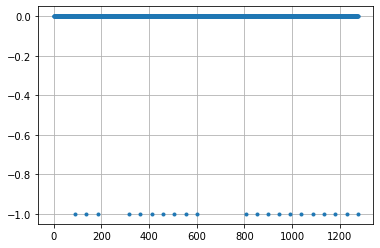

In [ ]:
# Выведем на графике полученные награды. Ненулевые награды за каждое очко будут отмечены точками
plt.plot(rewardList, '.') # точки будут награами на графике
ax = plt.gca() # получим текущие оси
ax.grid(True) # с фоновой сеткой

# Эффективно определяем вознаграждение

In [17]:
# Награды пока присваиваем только тем движениям, в момент после которых было пропущено или забито очко. Но так мы научимся не скоро.
# Нам нужно указать на важность действия чуть раньше, когда мы отбивали мяч ракеткой. Чтобы сетка поняла, что отбивать мяч - это хорошо,
# распределим награду на все шаги, предшествующему забитому/пропущенному мячу, причем чем давнее был шаг, тем меньше коэффицент награды он получит

####################
# Сформируем фукнцию, которая распределит ненулевую награду для всех шагов в удачном/неулачном розыгрыше
####################

def processRewards(rewardList):
  rewardDecay = 0.99  # установим высший коэффициент награды для ближнего действия к победному/проигрышному дейтвию.
  tmpReward = 0 #создадим временную переменную для награды
  rewardDecayed = np.zeros_like(rewardList, dtype=np.float32) # создадим новый массив из нулей для нового формата наград.

  for i in range(len(rewardList)-1, -1, -1): # будем идти в обратную сторону от награды с шагом -1
    if rewardList[i] == 0: # если  награда нулевая
      tmpReward = tmpReward * rewardDecay # зададим ей коэффициент
      rewardDecayed[i] = tmpReward # добавим в массив
    else:
      tmpReward = rewardList[i] # оставим награду неизменной
      rewardDecayed[i] = tmpReward # и введем в массив в неизменом виде
  # запустимнормализацию значений наград, что позводит сетке лучше  понимать, где были хорошие и плохие шаги
  rewardDecayed -= np.mean(rewardDecayed) # вычтем среднее
  rewardDecayed /= np.std(rewardDecayed) #разделим на стандартное отклонение
  return rewardDecayed

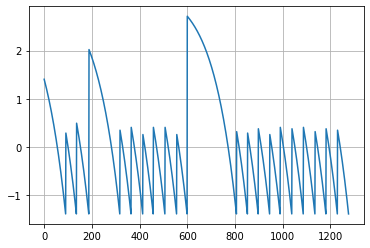

In [ ]:
# Посмотрим на распределение наград по новой функции
plt.plot(processRewards(rewardList), '-') #добавдяем в график награды с учетом новой функции
ax = plt.gca() # получим текущие оси
ax.grid(True) # c фоновой сеткой
# новое распределение наград даст лучшее отражение эффективности действий

# Пример игрового эпизода с последующей тренировкой сети

In [ ]:
# Сгенерируем новый игровой эпизод
statesList, upDownActionList, rewardList, networkOutputList = generateEpisode(policyNetworkModel)
# сыграли дло 21 очка, проиграли, получили списки всех состояний среды (кадров), шагов агента, вознаграждений и предсказаний

print('Количество состояний среды = ' + str(len(statesList)))
print('Форма состояний среды: ' + str(statesList[0].shape))
print('Список наград = ' + str(len(rewardList)))

Количество состояний среды = 1556
Форма состояний среды: (80, 80)
Список наград = 1556


In [ ]:
# Подготовим данные для тренировки
x = np.array(statesList) # зададим х как массив состояний
episodeReward = np.expand_dims(processRewards(rewardList), 1) # подобъем размер для входа в сетку
yTmp = np.array(upDownActionList) # зададим y как массив движений вверх(1)/вниз(0)
yTrue = np.expand_dims(yTmp, 1) # скорректируем форму под сетку

print('Форма наград за эпизод = ', episodeReward.shape)
print('Форма состоянйи среды = ', x.shape)
print('Форма фактических движений = ', yTrue.shape)

Форма наград за эпизод =  (1556, 1)
Форма состоянйи среды =  (1556, 80, 80)
Форма фактических движений =  (1556, 1)


In [ ]:
episodeReward[:20]

array([[1.0394665 ],
       [1.0344912 ],
       [1.0294656 ],
       [1.0243893 ],
       [1.0192617 ],
       [1.0140822 ],
       [1.0088505 ],
       [1.0035659 ],
       [0.99822795],
       [0.99283606],
       [0.98738974],
       [0.9818884 ],
       [0.97633153],
       [0.97071844],
       [0.96504873],
       [0.9593217 ],
       [0.9535368 ],
       [0.9476935 ],
       [0.9417912 ],
       [0.9358292 ]], dtype=float32)

In [ ]:
# скормим модели новые х и y
policyNetworkTrain.fit(x=[x, episodeReward], y=yTrue)

Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
Epoch 1/1
1556/1556 [==============================] - 0s 145us/step - loss: 4.6163e-04


In [18]:
#######################
# Теперь создадим серию игровых эпизодов 
# Затем предобработаем данные и скормим сети
#######################
def generateEpisodeBatchesTraining(model, nBatches=10): # подаем на вход заданное число игровых серий
  env = gym.make('Pong-v0')
  batchStateList = [] #зададим серию списоков состояний
  batchUpDownActionList = [] # серию списков движений
  batchRewardsList = [] # серию списков наград
  batchNetworkOutputList = [] # серию списков вероятностей идти вверх

  for i in range(nBatches): # для каждой серии
    statesList, upDownActionList, rewardList,networkOutputList = generateEpisode(model) # генерируем игровой эпизод
    # добавляем все списки состояний в серии списков
    batchStateList.extend(statesList)
    batchNetworkOutputList.extend(networkOutputList)
    batchUpDownActionList.extend(upDownActionList)
    batchRewardsList.extend(rewardList)

  episodeReward = np.expand_dims(processRewards(batchRewardsList), 1) # Задалим награды и изменим форму массива с добавлением оси
  x = np.array(batchStateList) #сформируем массив из серии списков состояний в качестве х для нейросети
  yTmp = np.array(batchUpDownActionList) # Задалим y как серию из списков движений вверх(1)/вниз(0)
  yTrue = np.expand_dims(yTmp, 1) # подгоним форму y для нейросети с добавлением оси
  
  history = policyNetworkTrain.fit(x=[x, episodeReward], y=yTrue, epochs=5, verbose=0) # скормим нейросети серию х и y

  batchLoss = history.history['loss'][-1]

  return batchStateList, batchUpDownActionList, batchRewardsList, batchNetworkOutputList, batchLoss
  # функция вернет серию списков состояний, списков движений, списков наград, списков из вероятностей идти вверх и серию ошибок

# Обучаем сеть на 10 тренировках

In [ ]:
trainingTimes = 10 # устанавливаем количество тренировок
for training in range(trainingTimes): # для каждой тренировки
  startTime = time.time()
  # сделаем по 10 игровых эпизодов
  statesList, upDownActionList, rewardList, networkOutputList, batchLoss = generateEpisodeBatchesTraining(policyNetworkModel, 10)
  endTime = time.time()

  print('Тренировка = ' + str((training) +1)) # выводим на экран номер очередной тренировки
  print('Время тренировки = ' + str(round(endTime - startTime)) + 'сек')
  print('Ошибка на тренировку = ' + str(round(batchLoss, 5)))
  rr = np.array(rewardList) # сформируем все награды
  print('Выиграли очков = ' + str(len(rr[rr>0])) + ' Проиграли очков = ' + str(len(rr[rr<0])))
  print()

  if training % 10 == 0: # через каждые 10 эпизодов
    policyNetworkModel.save('policyNetworkModel.h5') # сохраним модель в памяти
    policyNetworkModel.save('policyNetworkModel' + str(training) + '.h5') # для удобства сохраним модель в памяти с количеством тренировок в названии
    with open('rewardsModelSimple.txt', 'a') as recordingRewards: # также в текстовом файле будем вести записи с динамикой выигранных очков
      recordingRewards.write('training= ' + str(training) + 'выигранных очков = ' + str(len(rr[rr > 0])))
      recordingRewards.write('/n')

Тренировка = 1
Время тренировки = 51сек
Ошибка на тренировку = -0.02957
Выиграли очков = 5 Проиграли очков = 210

Тренировка = 2
Время тренировки = 56сек
Ошибка на тренировку = -0.03746
Выиграли очков = 5 Проиграли очков = 210

Тренировка = 3
Время тренировки = 63сек
Ошибка на тренировку = -0.04192
Выиграли очков = 13 Проиграли очков = 210

Тренировка = 4
Время тренировки = 65сек
Ошибка на тренировку = -0.06255
Выиграли очков = 8 Проиграли очков = 210

Тренировка = 5
Время тренировки = 61сек
Ошибка на тренировку = -0.05575
Выиграли очков = 6 Проиграли очков = 210

Тренировка = 6
Время тренировки = 62сек
Ошибка на тренировку = -0.08477
Выиграли очков = 5 Проиграли очков = 210

Тренировка = 7
Время тренировки = 67сек
Ошибка на тренировку = -0.0508
Выиграли очков = 8 Проиграли очков = 210

Тренировка = 8
Время тренировки = 70сек
Ошибка на тренировку = -0.04704
Выиграли очков = 16 Проиграли очков = 210

Тренировка = 9
Время тренировки = 77сек
Ошибка на тренировку = -0.04943
Выиграли очков 

## Выводы по результатам 10 тренировок.

До 7-й тренировки вигрывали 5-7 очков. После 8-й выигрыши составили 16, 21 и 19 очков.

# Обучаем сеть на 20 тренировках

In [ ]:
# Простая сеть с двумя слоями из 200 нейронов в скрытом слое и сигмоидой на выходе

inputs = Input(shape=(80, 80)) # на входном слое сетки изображение 80х80
flattenedLayer = Flatten()(inputs) # переводим в вектор
fullConnected = Dense(units=200, activation='relu', use_bias=False)(flattenedLayer) # Задали 200 нейронов и активацию relu
sigmoidOutput = Dense(1, activation='sigmoid', use_bias=False)(fullConnected)
policyNetworkModel = Model(inputs=inputs, outputs=sigmoidOutput)
policyNetworkModel.summary()


Model: "model_8"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_6 (InputLayer)         (None, 80, 80)            0         
_________________________________________________________________
flatten_6 (Flatten)          (None, 6400)              0         
_________________________________________________________________
dense_11 (Dense)             (None, 200)               1280000   
_________________________________________________________________
dense_12 (Dense)             (None, 1)                 200       
Total params: 1,280,200
Trainable params: 1,280,200
Non-trainable params: 0
_________________________________________________________________


In [ ]:
####################
# создаем керас-оптимизатор и нейронку для обучения
####################
episodeReward = Input(shape=(1,), name='episodeReward')  # задаем награду за эпизод
policyNetworkTrain = Model(inputs=[inputs, episodeReward], outputs=sigmoidOutput) # создаем сеть с добавлением на вход награды

myOptimizer = RMSprop(lr=0.0001)
policyNetworkTrain.compile(optimizer=myOptimizer, loss=rewardedLoss(episodeReward)) # компилируем сеть с новой функцией потерь policy

In [ ]:
trainingTimes = 20 # устанавливаем количество тренировок
for training in range(trainingTimes): # для каждой тренировки
  startTime = time.time()
  # сделаем по 10 игровых эпизодов
  statesList, upDownActionList, rewardList, networkOutputList, batchLoss = generateEpisodeBatchesTraining(policyNetworkModel, 10)
  endTime = time.time()

  print('Тренировка = ' + str((training) +1)) # выводим на экран номер очередной тренировки
  print('Время тренировки = ' + str(round(endTime - startTime)) + 'сек')
  print('Ошибка на тренировку = ' + str(round(batchLoss, 5)))
  rr = np.array(rewardList) # сформируем все награды
  print('Выиграли очков = ' + str(len(rr[rr>0])) + ' Проиграли очков = ' + str(len(rr[rr<0])))
  print()

  if training % 10 == 0: # через каждые 10 эпизодов
    policyNetworkModel.save('policyNetworkModel.h5') # сохраним модель в памяти
    policyNetworkModel.save('policyNetworkModel' + str(training) + '.h5') # для удобства сохраним модель в памяти с количеством тренировок в названии
    with open('rewardsModelSimple.txt', 'a') as recordingRewards: # также в текстовом файле будем вести записи с динамикой выигранных очков
      recordingRewards.write('training= ' + str(training) + 'выигранных очков = ' + str(len(rr[rr > 0])))
      recordingRewards.write('/n')

Тренировка = 1
Время тренировки = 55сек
Ошибка на тренировку = -0.03289
Выиграли очков = 6 Проиграли очков = 210

Тренировка = 2
Время тренировки = 58сек
Ошибка на тренировку = -0.0467
Выиграли очков = 7 Проиграли очков = 210

Тренировка = 3
Время тренировки = 54сек
Ошибка на тренировку = -0.07102
Выиграли очков = 4 Проиграли очков = 210

Тренировка = 4
Время тренировки = 68сек
Ошибка на тренировку = -0.04134
Выиграли очков = 10 Проиграли очков = 210

Тренировка = 5
Время тренировки = 69сек
Ошибка на тренировку = -0.06829
Выиграли очков = 8 Проиграли очков = 210

Тренировка = 6
Время тренировки = 70сек
Ошибка на тренировку = -0.05835
Выиграли очков = 6 Проиграли очков = 210

Тренировка = 7
Время тренировки = 72сек
Ошибка на тренировку = -0.05233
Выиграли очков = 13 Проиграли очков = 210

Тренировка = 8
Время тренировки = 83сек
Ошибка на тренировку = -0.06188
Выиграли очков = 13 Проиграли очков = 210

Тренировка = 9
Время тренировки = 78сек
Ошибка на тренировку = -0.072
Выиграли очков =

## Выводы по результатам 20 тренировок

Также как и в прошлый раз количество выигранных очков увепличилось  вдвое после 6-й тренировки (с 6 до 13). После 14-й тренировки количество выигранных очков колебалось около 20. Один раз сеть выиграла 35 очков, но поскольку это разовый эпизод, полагаю, что это случайность.

# Обучаем сеть на 30 тренировках

In [ ]:
# Простая сеть с двумя слоями из 200 нейронов в скрытом слое и сигмоидой на выходе

inputs = Input(shape=(80, 80)) # на входном слое сетки изображение 80х80
flattenedLayer = Flatten()(inputs) # переводим в вектор
fullConnected = Dense(units=200, activation='relu', use_bias=False)(flattenedLayer) # Задали 200 нейронов и активацию relu
sigmoidOutput = Dense(1, activation='sigmoid', use_bias=False)(fullConnected)
policyNetworkModel = Model(inputs=inputs, outputs=sigmoidOutput)
policyNetworkModel.summary()


Model: "model_12"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_8 (InputLayer)         (None, 80, 80)            0         
_________________________________________________________________
flatten_8 (Flatten)          (None, 6400)              0         
_________________________________________________________________
dense_15 (Dense)             (None, 200)               1280000   
_________________________________________________________________
dense_16 (Dense)             (None, 1)                 200       
Total params: 1,280,200
Trainable params: 1,280,200
Non-trainable params: 0
_________________________________________________________________


In [ ]:
####################
# создаем керас-оптимизатор и нейронку для обучения
####################
episodeReward = Input(shape=(1,), name='episodeReward')  # задаем награду за эпизод
policyNetworkTrain = Model(inputs=[inputs, episodeReward], outputs=sigmoidOutput) # создаем сеть с добавлением на вход награды

myOptimizer = RMSprop(lr=0.0001)
policyNetworkTrain.compile(optimizer=myOptimizer, loss=rewardedLoss(episodeReward)) # компилируем сеть с новой функцией потерь policy

In [ ]:
trainingTimes = 30 # устанавливаем количество тренировок
for training in range(trainingTimes): # для каждой тренировки
  startTime = time.time()
  # сделаем по 10 игровых эпизодов
  statesList, upDownActionList, rewardList, networkOutputList, batchLoss = generateEpisodeBatchesTraining(policyNetworkModel, 10)
  endTime = time.time()

  print('Тренировка = ' + str((training) +1)) # выводим на экран номер очередной тренировки
  print('Время тренировки = ' + str(round(endTime - startTime)) + 'сек')
  print('Ошибка на тренировку = ' + str(round(batchLoss, 5)))
  rr = np.array(rewardList) # сформируем все награды
  print('Выиграли очков = ' + str(len(rr[rr>0])) + ' Проиграли очков = ' + str(len(rr[rr<0])))
  print()

  if training % 10 == 0: # через каждые 10 эпизодов
    policyNetworkModel.save('policyNetworkModel.h5') # сохраним модель в памяти
    policyNetworkModel.save('policyNetworkModel' + str(training) + '.h5') # для удобства сохраним модель в памяти с количеством тренировок в названии
    with open('rewardsModelSimple.txt', 'a') as recordingRewards: # также в текстовом файле будем вести записи с динамикой выигранных очков
      recordingRewards.write('training= ' + str(training) + 'выигранных очков = ' + str(len(rr[rr > 0])))
      recordingRewards.write('/n')

Тренировка = 1
Время тренировки = 51сек
Ошибка на тренировку = -0.0322
Выиграли очков = 6 Проиграли очков = 210

Тренировка = 2
Время тренировки = 53сек
Ошибка на тренировку = -0.03876
Выиграли очков = 4 Проиграли очков = 210

Тренировка = 3
Время тренировки = 60сек
Ошибка на тренировку = -0.05645
Выиграли очков = 12 Проиграли очков = 210

Тренировка = 4
Время тренировки = 56сек
Ошибка на тренировку = -0.04863
Выиграли очков = 8 Проиграли очков = 210

Тренировка = 5
Время тренировки = 61сек
Ошибка на тренировку = -0.04851
Выиграли очков = 10 Проиграли очков = 210

Тренировка = 6
Время тренировки = 66сек
Ошибка на тренировку = -0.04177
Выиграли очков = 15 Проиграли очков = 210

Тренировка = 7
Время тренировки = 66сек
Ошибка на тренировку = -0.06135
Выиграли очков = 13 Проиграли очков = 210

Тренировка = 8
Время тренировки = 65сек
Ошибка на тренировку = -0.07423
Выиграли очков = 11 Проиграли очков = 210

Тренировка = 9
Время тренировки = 72сек
Ошибка на тренировку = -0.05444
Выиграли очк

## Выводы по результатам 30 тренировок.

В этот раз большой прорыв произошел уже к третьей тренировке, количество выигранных очков поднялось до 13. Потом оно медленно поднималось вверх в сторону 20-ти. На 13 эпохе произошел еще один прорыв, количество выигранных очков поднялось до 33. В дальнейшемколебалось между 35 и 50. Максимальное количество выигранных очков составило 57 на 19 тренировке.

# Изменение архитектуры сети.

Все эксперименты буду проводить на 15 тренировках, поскольку это более менее оптимальный вариант по длительности.

## Изменим количество нейронов в Dense-слое.

In [ ]:
# Изменим количество нейронов на 128, 256, 512

num_neirons_list = [128, 256, 512]
for num_neirons in num_neirons_list:
  print()
  print('Количество нейронов: ', num_neirons)
  print()

  # Создаем сеть
  inputs = Input(shape=(80, 80)) # на входном слое сетки изображение 80х80
  flattenedLayer = Flatten()(inputs) # переводим в вектор
  fullConnected = Dense(units=num_neirons, activation='relu', use_bias=False)(flattenedLayer) # Задали 200 нейронов и активацию relu
  sigmoidOutput = Dense(1, activation='sigmoid', use_bias=False)(fullConnected)
  policyNetworkModel = Model(inputs=inputs, outputs=sigmoidOutput)
  policyNetworkModel.summary()

  ####################
  # создаем керас-оптимизатор и нейронку для обучения
  ####################
  episodeReward = Input(shape=(1,), name='episodeReward')  # задаем награду за эпизод
  policyNetworkTrain = Model(inputs=[inputs, episodeReward], outputs=sigmoidOutput) # создаем сеть с добавлением на вход награды

  myOptimizer = RMSprop(lr=0.0001)
  policyNetworkTrain.compile(optimizer=myOptimizer, loss=rewardedLoss(episodeReward)) # компилируем сеть с новой функцией потерь policy

# обучение на 15 тренировках
  trainingTimes = 15 # устанавливаем количество тренировок
  for training in range(trainingTimes): # для каждой тренировки
    startTime = time.time()
    # сделаем по 10 игровых эпизодов
    statesList, upDownActionList, rewardList, networkOutputList, batchLoss = generateEpisodeBatchesTraining(policyNetworkModel, 10)
    endTime = time.time()

    print('Тренировка = ' + str((training) +1)) # выводим на экран номер очередной тренировки
    print('Время тренировки = ' + str(round(endTime - startTime)) + 'сек')
    print('Ошибка на тренировку = ' + str(round(batchLoss, 5)))
    rr = np.array(rewardList) # сформируем все награды
    print('Выиграли очков = ' + str(len(rr[rr>0])) + ' Проиграли очков = ' + str(len(rr[rr<0])))
    print()

    if training % 10 == 0: # через каждые 10 эпизодов
      policyNetworkModel.save('policyNetworkModel.h5') # сохраним модель в памяти
      policyNetworkModel.save('policyNetworkModel' + str(training) + '.h5') # для удобства сохраним модель в памяти с количеством тренировок в названии
      with open('rewardsModelSimple.txt', 'a') as recordingRewards: # также в текстовом файле будем вести записи с динамикой выигранных очков
        recordingRewards.write('training= ' + str(training) + 'выигранных очков = ' + str(len(rr[rr > 0])))
        recordingRewards.write('/n')


Количество нейронов:  128

Model: "model_22"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_13 (InputLayer)        (None, 80, 80)            0         
_________________________________________________________________
flatten_13 (Flatten)         (None, 6400)              0         
_________________________________________________________________
dense_25 (Dense)             (None, 128)               819200    
_________________________________________________________________
dense_26 (Dense)             (None, 1)                 128       
Total params: 819,328
Trainable params: 819,328
Non-trainable params: 0
_________________________________________________________________
Тренировка = 1
Время тренировки = 57сек
Ошибка на тренировку = -0.02459
Выиграли очков = 7 Проиграли очков = 210

Тренировка = 2
Время тренировки = 54сек
Ошибка на тренировку = -0.03518
Выиграли очков = 6 Проиграли очков =

## Выводы по результатам изменения количества нейронов.

При количестве нейронов 128 наблюдался  рост качества игры рывками. На 4 тренировке количество увеличилось до 16, на 7 - до 23, на 13 - до 27. 

При количестве нейронов 256 наблдался более устойчивый рост. Количество выигранных очков увеличивалось, не смотря на колебания, к концу поднявшись до 23-26 очков. 

При количестве нейронов 512 рост наблюдался слабый. До 10-й тренировки количество выигранных очков колебалось около 10. Позже пошло немного вверх и только на последней тренировке достигло 22 очков.

Оптимальном в данном случае является количество в 256 нейронов. Именно это количетво показало самый лучщий результат и, что важно, устойчивое развитие. Увеличение до 512 нейронов сказалось негативно, модель начала обучаться хуже.

## Добавим Dense-слой.

Чтобы получить подходящий для сравнения результат используем изначальное количество нейронов (200).

In [ ]:
# Создаем сеть
inputs = Input(shape=(80, 80)) # на входном слое сетки изображение 80х80
flattenedLayer = Flatten()(inputs) # переводим в вектор
fullConnected = Dense(units=200, activation='relu', use_bias=False)(flattenedLayer) # Задали 200 нейронов и активацию relu
fullConnected = Dense(units=200, activation='relu', use_bias=False)(fullConnected) # Задаем второй слой на 200 нейронов
sigmoidOutput = Dense(1, activation='sigmoid', use_bias=False)(fullConnected)
policyNetworkModel = Model(inputs=inputs, outputs=sigmoidOutput)
policyNetworkModel.summary()

####################
# создаем керас-оптимизатор и нейронку для обучения
####################
episodeReward = Input(shape=(1,), name='episodeReward')  # задаем награду за эпизод
policyNetworkTrain = Model(inputs=[inputs, episodeReward], outputs=sigmoidOutput) # создаем сеть с добавлением на вход награды
 
myOptimizer = RMSprop(lr=0.0001)
policyNetworkTrain.compile(optimizer=myOptimizer, loss=rewardedLoss(episodeReward)) # компилируем сеть с новой функцией потерь policy

# обучение на 15 тренировках
trainingTimes = 15 # устанавливаем количество тренировок
for training in range(trainingTimes): # для каждой тренировки
  startTime = time.time()
  # сделаем по 10 игровых эпизодов
  statesList, upDownActionList, rewardList, networkOutputList, batchLoss = generateEpisodeBatchesTraining(policyNetworkModel, 10)
  endTime = time.time()

  print('Тренировка = ' + str((training) +1)) # выводим на экран номер очередной тренировки
  print('Время тренировки = ' + str(round(endTime - startTime)) + 'сек')
  print('Ошибка на тренировку = ' + str(round(batchLoss, 5)))
  rr = np.array(rewardList) # сформируем все награды
  print('Выиграли очков = ' + str(len(rr[rr>0])) + ' Проиграли очков = ' + str(len(rr[rr<0])))
  print()

  if training % 10 == 0: # через каждые 10 эпизодов
    policyNetworkModel.save('policyNetworkModel.h5') # сохраним модель в памяти
    policyNetworkModel.save('policyNetworkModel' + str(training) + '.h5') # для удобства сохраним модель в памяти с количеством тренировок в названии
    with open('rewardsModelSimple.txt', 'a') as recordingRewards: # также в текстовом файле будем вести записи с динамикой выигранных очков
      recordingRewards.write('training= ' + str(training) + 'выигранных очков = ' + str(len(rr[rr > 0])))
      recordingRewards.write('/n')

Model: "model_28"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_16 (InputLayer)        (None, 80, 80)            0         
_________________________________________________________________
flatten_16 (Flatten)         (None, 6400)              0         
_________________________________________________________________
dense_31 (Dense)             (None, 200)               1280000   
_________________________________________________________________
dense_32 (Dense)             (None, 200)               40000     
_________________________________________________________________
dense_33 (Dense)             (None, 1)                 200       
Total params: 1,320,200
Trainable params: 1,320,200
Non-trainable params: 0
_________________________________________________________________
Тренировка = 1
Время тренировки = 60сек
Ошибка на тренировку = -0.0758
Выиграли очков = 9 Проиграли очков = 210

Т

## Выводы по результатам добавления Dense-слоя.

В данном случай наблюдаются большие скачки в результатах. То модель выигрывает 21 очко, потом 3, потом 22, потом 4 и т.п. Из-за этого рост происходит медленно. Кстати, до этого модель ни разу проигрывала полность. Здесь трижды набрала 0 очков.
На двух последних тренировках набрала сначала 35 потом 21 очко.

Добавление Dense-слоя не принесло успеха, даже снизило эффективность обучения.

## Добавим Conv-слой.

Чтобы получить подходящий для сравнения результат используем изначальное количество нейронов (200).

In [ ]:
# Создаем сеть
inputs = Input(shape=(80, 80, 1)) # на входном слое сетки изображение 80х80

convLayer = Conv2D(200, (3, 3), padding='same', activation='relu')(inputs)

flattenedLayer = Flatten()(convLayer) # переводим в вектор
fullConnected = Dense(units=200, activation='relu', use_bias=False)(flattenedLayer) # Задали 200 нейронов и активацию relu
sigmoidOutput = Dense(1, activation='sigmoid', use_bias=False)(fullConnected)
policyNetworkModel = Model(inputs=inputs, outputs=sigmoidOutput)
policyNetworkModel.summary()

####################
# создаем керас-оптимизатор и нейронку для обучения
####################
episodeReward = Input(shape=(1,), name='episodeReward')  # задаем награду за эпизод
policyNetworkTrain = Model(inputs=[inputs, episodeReward], outputs=sigmoidOutput) # создаем сеть с добавлением на вход награды
 
myOptimizer = RMSprop(lr=0.0001)
policyNetworkTrain.compile(optimizer=myOptimizer, loss=rewardedLoss(episodeReward)) # компилируем сеть с новой функцией потерь policy

# обучение на 15 тренировках
trainingTimes = 15 # устанавливаем количество тренировок
for training in range(trainingTimes): # для каждой тренировки
  startTime = time.time()
  # сделаем по 10 игровых эпизодов
  statesList, upDownActionList, rewardList, networkOutputList, batchLoss = generateEpisodeBatchesTraining(policyNetworkModel, 10)
  endTime = time.time()

  print('Тренировка = ' + str((training) +1)) # выводим на экран номер очередной тренировки
  print('Время тренировки = ' + str(round(endTime - startTime)) + 'сек')
  print('Ошибка на тренировку = ' + str(round(batchLoss, 5)))
  rr = np.array(rewardList) # сформируем все награды
  print('Выиграли очков = ' + str(len(rr[rr>0])) + ' Проиграли очков = ' + str(len(rr[rr<0])))
  print()

  if training % 10 == 0: # через каждые 10 эпизодов
    policyNetworkModel.save('policyNetworkModel.h5') # сохраним модель в памяти
    policyNetworkModel.save('policyNetworkModel' + str(training) + '.h5') # для удобства сохраним модель в памяти с количеством тренировок в названии
    with open('rewardsModelSimple.txt', 'a') as recordingRewards: # также в текстовом файле будем вести записи с динамикой выигранных очков
      recordingRewards.write('training= ' + str(training) + 'выигранных очков = ' + str(len(rr[rr > 0])))
      recordingRewards.write('/n')

Model: "model_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_3 (InputLayer)         (None, 80, 80, 1)         0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 80, 80, 200)       2000      
_________________________________________________________________
flatten_3 (Flatten)          (None, 1280000)           0         
_________________________________________________________________
dense_5 (Dense)              (None, 200)               256000000 
_________________________________________________________________
dense_6 (Dense)              (None, 1)                 200       
Total params: 256,002,200
Trainable params: 256,002,200
Non-trainable params: 0
_________________________________________________________________
Тренировка = 1
Время тренировки = 428сек
Ошибка на тренировку = 0.00758
Выиграли очков = 9 Проиграли очков = 21

## Выводы по результатам добавления Conv-слоя.

Модель обучалась очень долго, каждая тренировка около 400 сек. при том, что ранее на одну тренировку уходило около 70-90 сек. Это объяснимо, потому что количество связей в модели возрасло с 3 000 000 до 256 000 000. 
Однако с обучением произошло странное. На первой тренировке модель выиграла 9 очков. На всех последующих тренировках она не выиграла ни очка ни разу. Добавление Conv-слоя в данном случае привело к полной неспособности модели обучаться. Не знаю, почему.